In [1]:
#Bank Loan Data Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import plotly.express as px

In [2]:
df=pd.read_excel("/content/financial_loan.xlsx")

In [ ]:
df.head()

,id,address_state,application_type,emp_length,emp_title,grade,home_ownership,issue_date,last_credit_pull_date,last_payment_date,...,sub_grade,term,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,total_payment
0,1077430,GA,INDIVIDUAL,< 1 year,Ryder,C,RENT,2021-02-11,2021-09-13,2021-04-13,...,C4,60 months,Source Verified,30000.0,0.0100,59.83,0.1527,2500,4,1009
1,1072053,CA,INDIVIDUAL,9 years,MKC Accounting,E,RENT,2021-01-01,2021-12-14,2021-01-15,...,E1,36 months,Source Verified,48000.0,0.0535,109.43,0.1864,3000,4,3939
2,1069243,CA,INDIVIDUAL,4 years,Chemat Technology Inc,C,RENT,2021-01-05,2021-12-12,2021-01-09,...,C5,36 months,Not Verified,50000.0,0.2088,421.65,0.1596,12000,11,3522
3,1041756,TX,INDIVIDUAL,< 1 year,barnes distribution,B,MORTGAGE,2021-02-25,2021-12-12,2021-03-12,...,B2,60 months,Source Verified,42000.0,0.0540,97.06,0.1065,4500,9,4911
4,1068350,IL,INDIVIDUAL,10+ years,J&J Steel Inc,A,MORTGAGE,2021-01-01,2021-12-14,2021-01-15,...,A1,36 months,Verified,83000.0,0.0231,106.53,0.0603,3500,28,3835


In [ ]:
df.shape

(38576, 24)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id                     38576 non-null  int64         
 1   address_state          38576 non-null  object        
 2   application_type       38576 non-null  object        
 3   emp_length             38576 non-null  object        
 4   emp_title              37138 non-null  object        
 5   grade                  38576 non-null  object        
 6   home_ownership         38576 non-null  object        
 7   issue_date             38576 non-null  datetime64[ns]
 8   last_credit_pull_date  38576 non-null  datetime64[ns]
 9   last_payment_date      38576 non-null  datetime64[ns]
 10  loan_status            38576 non-null  object        
 11  next_payment_date      38576 non-null  datetime64[ns]
 12  member_id              38576 non-null  int64         
 13  p

In [ ]:
df.dtypes

,0
id,int64
address_state,object
application_type,object
emp_length,object
emp_title,object
grade,object
home_ownership,object
issue_date,datetime64[ns]
last_credit_pull_date,datetime64[ns]
last_payment_date,datetime64[ns]


In [ ]:
df.describe

<bound method NDFrame.describe of             id address_state application_type emp_length  \
0      1077430            GA       INDIVIDUAL   < 1 year   
1      1072053            CA       INDIVIDUAL    9 years   
2      1069243            CA       INDIVIDUAL    4 years   
3      1041756            TX       INDIVIDUAL   < 1 year   
4      1068350            IL       INDIVIDUAL  10+ years   
...        ...           ...              ...        ...   
38571   803452            NJ       INDIVIDUAL   < 1 year   
38572   970377            NY       INDIVIDUAL    8 years   
38573   875376            CA       INDIVIDUAL    5 years   
38574   972997            NY       INDIVIDUAL    5 years   
38575   682952            NY       INDIVIDUAL    4 years   

                             emp_title grade home_ownership issue_date  \
0                                Ryder     C           RENT 2021-02-11   
1                       MKC Accounting     E           RENT 2021-01-01   
2                Chemat Technology Inc     C           RENT 2021-01-05   
3                  barnes distribution     B       MORTGAGE 2021-02-25   
4                        J&J Steel Inc     A       MORTGAGE 2021-01-01   
...                                ...   ...            ...        ...   
38571         Joseph M Sanzari Company     C       MORTGAGE 2021-07-11   
38572                        Swat Fame     C           RENT 2021-10-11   
38573  Anaheim Regional Medical Center     D           RENT 2021-09-11   
38574               Brooklyn Radiology     D           RENT 2021-10-11   
38575                    Allen Edmonds     F           RENT 2021-07-11   

      last_credit_pull_date last_payment_date  ... sub_grade        term  \
0                2021-09-13        2021-04-13  ...        C4   60 months   
1                2021-12-14        2021-01-15  ...        E1   36 months   
2                2021-12-12        2021-01-09  ...        C5   36 months   
3                2021-12-12        2021-03-12  ...        B2   60 months   
4                2021-12-14        2021-01-15  ...        A1   36 months   
...                     ...               ...  ...       ...         ...   
38571            2021-05-16        2021-05-16  ...        C1   60 months   
38572            2021-04-16        2021-05-16  ...        C1   60 months   
38573            2021-05-16        2021-05-16  ...        D5   60 months   
38574            2021-05-16        2021-05-16  ...        D5   60 months   
38575            2021-05-16        2021-05-16  ...        F3   60 months   

       verification_status annual_income     dti installment int_rate  \
0          Source Verified       30000.0  0.0100       59.83   0.1527   
1          Source Verified       48000.0  0.0535      109.43   0.1864   
2             Not Verified       50000.0  0.2088      421.65   0.1596   
3          Source Verified       42000.0  0.0540       97.06   0.1065   
4                 Verified       83000.0  0.0231      106.53   0.0603   
...                    ...           ...     ...         ...      ...   
38571             Verified      100000.0  0.1986      551.64   0.1299   
38572             Verified       50000.0  0.0458      579.72   0.1349   
38573             Verified       65000.0  0.1734      627.93   0.1749   
38574             Verified      368000.0  0.0009      612.72   0.1825   
38575             Verified       80000.0  0.0600      486.86   0.2099   

       loan_amount  total_acc  total_payment  
0             2500          4           1009  
1             3000          4           3939  
2            12000         11           3522  
3             4500          9           4911  
4             3500         28           3835  
...            ...        ...            ...  
38571        24250         33          31946  
38572        25200         18          31870  
38573        25000         20          35721  
38574        24000          9          33677  
38575        18000          7          27679  

[

In [ ]:
total_loan_application=df['id'].count()
print("Total Loan Applications:",total_loan_application)

Total Loan Applications: 38576


In [ ]:
latest_issue_data=df['issue_date'].max()
latest_year=latest_issue_data.year
latest_month=latest_issue_data.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month==latest_month)]
mtd_loan_applications=mtd_data['id'].count()
print(f"MTD Loan Application(for{latest_issue_data.strftime('%B %Y')}) : {mtd_loan_applications}")

MTD Loan Application(forDecember 2021) : 4314


In [ ]:
# Total Funded Amount
total_funded_amount=df['loan_amount'].sum()
total_funded_amount_millions=total_funded_amount/1000000
print("Total Funded Amount:${:.2f}M".format(total_funded_amount_millions))

Total Funded Amount:$435.76M


In [ ]:
latest_issue_data=df['issue_date'].max()
latest_year=latest_issue_data.year
latest_month=latest_issue_data.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_funded_amount=mtd_data['loan_amount'].sum()
mtd_total_funded_amount_millions=mtd_total_funded_amount/1000000
print("MTD Total Funded Amount : ${:.2f}M".format(mtd_total_funded_amount_millions))




MTD Total Funded Amount : $53.98M


In [ ]:
#Total Amount Received
total_amount_recieved=df['total_payment'].sum()
total_amount_recieved_millions=total_amount_recieved/1000000
print("Total Amount Recieved : ${:.2f}M".format(total_amount_recieved_millions))


Total Amount Recieved : $473.07M


In [ ]:
latest_issue_data=df['issue_date'].max()
latest_year=latest_issue_data.year
latest_month=latest_issue_data.month
mtd_data=df[(df['issue_date'].dt.year == latest_year) & (df['issue_date'].dt.month==latest_month)]

mtd_total_amount_recieved=mtd_data['total_payment'].sum()
mtd_total_amount_recieved_millions=mtd_total_amount_recieved/1000000
print("MTD Total Amount Recieved : ${:.2f}M".format(mtd_total_amount_recieved_millions))


MTD Total Amount Recieved : $58.07M


In [ ]:
#Average Interest Rate
average_interest_rate=df['int_rate'].mean()*100
print("Average Interest Rate :{:.2f}%".format(average_interest_rate))

Average Interest Rate :12.05%


In [ ]:
#Average-Debit-to-Income-Ratio (DTI)
average_dti=df['dti'].mean()*100
print("Average DTI:{:.2f}% ".format(average_dti))

Average DTI:13.33% 


In [ ]:
#Good Loan Metrices
good_loans = df[df["loan_status"].isin(["Fully Paid", "Current"])] #Good Loans

total_loan_applications=df['id'].count()

good_loan_applications = good_loans['id'].count()

good_loan_funded_amount=good_loans['loan_amount'].sum()

good_loan_received = good_loans['total_payment'].sum()

good_loan_funded_amount_millions = good_loan_funded_amount / 1000000

good_loan_received_millions = good_loan_received / 1000000

good_loan_percentage =(good_loan_applications / total_loan_applications)*100

print("Good Loan Applications:", good_loan_applications)

print("Good Loan Funded Amount (in Millions): ${:.2f}M".format(good_loan_funded_amount_millions))

print("Good Loan Total Received (in Millions): ${:.2f}M".format(good_loan_received_millions))

print("Percentage of Good Loan Applications: {:.2f}%".format(good_loan_percentage))

Good Loan Applications: 33243
Good Loan Funded Amount (in Millions): $370.22M
Good Loan Total Received (in Millions): $435.79M
Percentage of Good Loan Applications: 86.18%


In [ ]:
#Bad Loan Metrices
bad_loans = df[df["loan_status"].isin(["Charged Off"])] #Bad Loans

total_loan_applications=df['id'].count()

bad_loan_applications =bad_loans['id'].count()

bad_loan_funded_amount=bad_loans['loan_amount'].sum()

bad_loan_received = bad_loans['total_payment'].sum()

bad_loan_funded_amount_millions = bad_loan_funded_amount / 1000000

bad_loan_received_millions = bad_loan_received / 1000000

bad_loan_percentage =(bad_loan_applications / total_loan_applications)*100

print("Bad Loan Applications:", bad_loan_applications)

print("Bad Loan Funded Amount (in Millions): ${:.2f}M".format(bad_loan_funded_amount_millions))

print("Bad Loan Total Received (in Millions): ${:.2f}M".format(bad_loan_received_millions))

print("Percentage of Bad Loan Applications: {:.2f}%".format(bad_loan_percentage))

Bad Loan Applications: 5333
Bad Loan Funded Amount (in Millions): $65.53M
Bad Loan Total Received (in Millions): $37.28M
Percentage of Bad Loan Applications: 13.82%


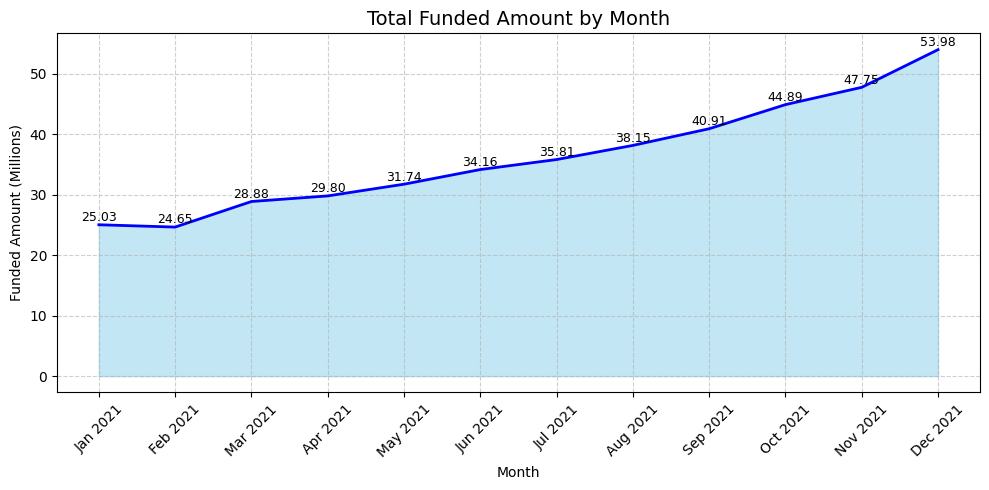

In [ ]:
#Monthly Trends by Issue Date For Total Funded Amount
monthly_funded =(
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['loan_amount']
      .sum()
      .div(1_000_000)
      .reset_index(name='loan_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='skyblue',alpha=0.5)

plt.plot(monthly_funded['month_name'],monthly_funded['loan_amount_millions'],color='blue',linewidth=2)

for i, row in monthly_funded.iterrows():
    plt.text(i,row['loan_amount_millions'] + 0.1,f"{row['loan_amount_millions']:.2f}",
        ha='center',va='bottom',fontsize=9,rotation=0,color='black')

plt.title('Total Funded Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Funded Amount (Millions)')
plt.xticks(ticks=range(len(monthly_funded)),labels=monthly_funded['month_name'],rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


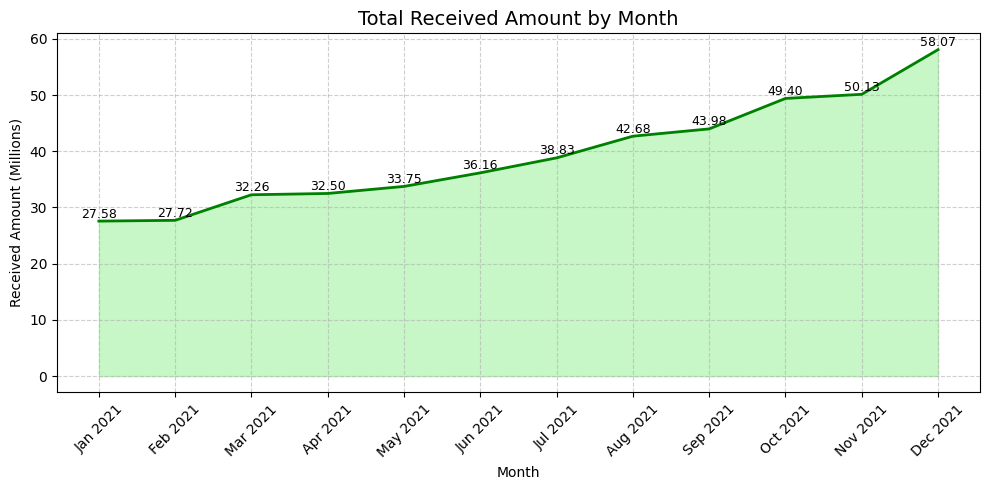

In [ ]:
#Monthly Trends by Issue Date For Total Amount Received
monthly_received = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['total_payment']
      .sum()
      .div(1_000_000)
      .reset_index(name='received_amount_millions')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    range(len(monthly_received)),
    monthly_received['received_amount_millions'],
    color='lightgreen',
    alpha=0.5
)

plt.plot(
    range(len(monthly_received)),
    monthly_received['received_amount_millions'],
    color='green',
    linewidth=2
)

for i, row in monthly_received.iterrows():
    plt.text(
        i,
        row['received_amount_millions'] + 0.1,
        f"{row['received_amount_millions']:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Received Amount by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Received Amount (Millions)')

plt.xticks(
    ticks=range(len(monthly_received)),
    labels=monthly_received['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


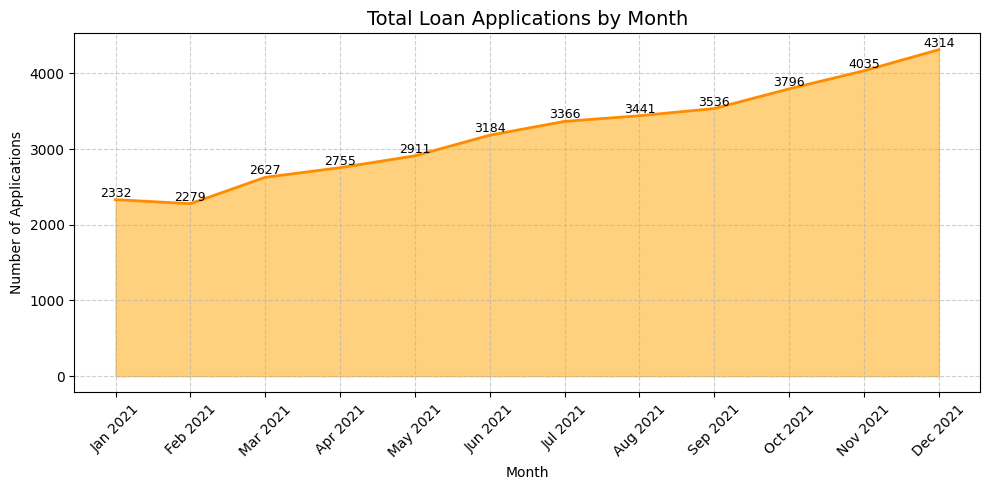

In [ ]:
# Monthly Trends by Issue Date For Total Loan Applications
# Monthly Trends by Issue Date For Total Loan Applications
monthly_applications = (
    df.sort_values('issue_date')
      .assign(month_name=lambda x: x['issue_date'].dt.strftime('%b %Y'))
      .groupby('month_name', sort=False)['id']
      .count()
      .reset_index(name='loan_applications_count')
)

plt.figure(figsize=(10, 5))

plt.fill_between(
    range(len(monthly_applications)),
    monthly_applications['loan_applications_count'],
    color='orange',
    alpha=0.5
)

plt.plot(
    range(len(monthly_applications)),
    monthly_applications['loan_applications_count'],
    color='darkorange',
    linewidth=2
)

for i, row in monthly_applications.iterrows():
    plt.text(
        i,
        row['loan_applications_count'] + 0.5,
        f"{row['loan_applications_count']}",
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0,
        color='black'
    )

plt.title('Total Loan Applications by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Applications')

plt.xticks(
    ticks=range(len(monthly_applications)),
    labels=monthly_applications['month_name'],
    rotation=45
)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


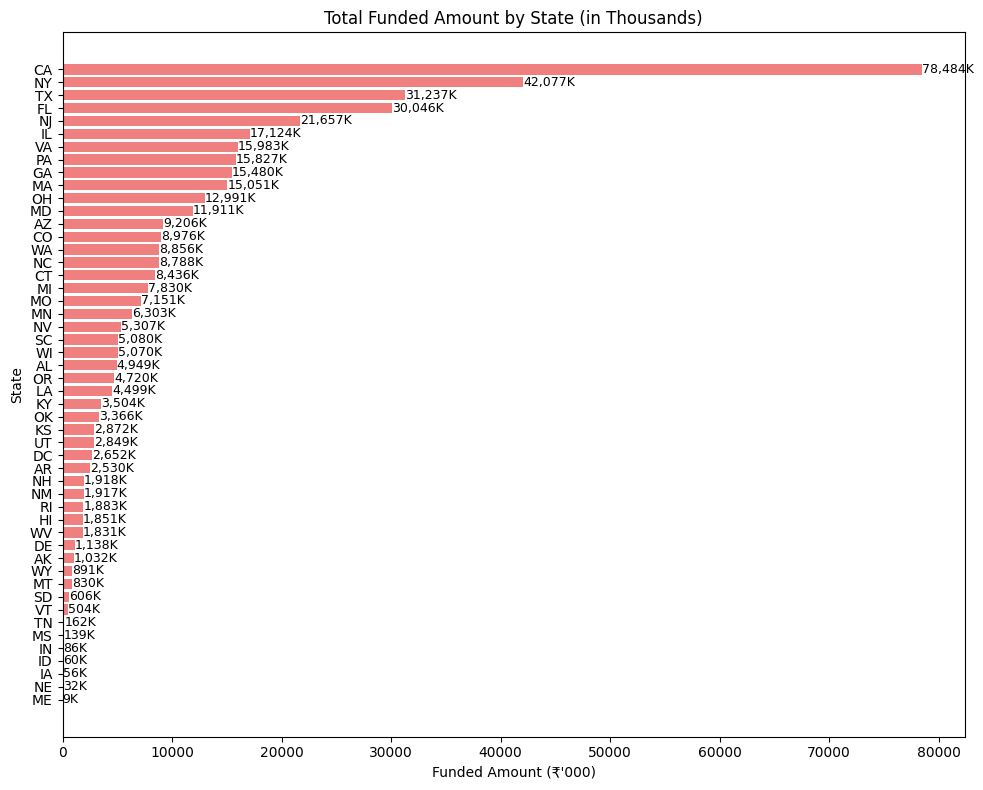

In [8]:
# Regional Analysis by State for Total Funded Amount
state_funding = df.groupby('address_state')['loan_amount'].sum().sort_values(ascending=True)
state_funding_thousands = state_funding / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_funding_thousands.index,
                state_funding_thousands.values,
                color='lightcoral')

for bar in bars:
    width = bar.get_width()
    plt.text(width + 10,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.title('Total Funded Amount by State (in Thousands)')
plt.xlabel("Funded Amount (₹'000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()



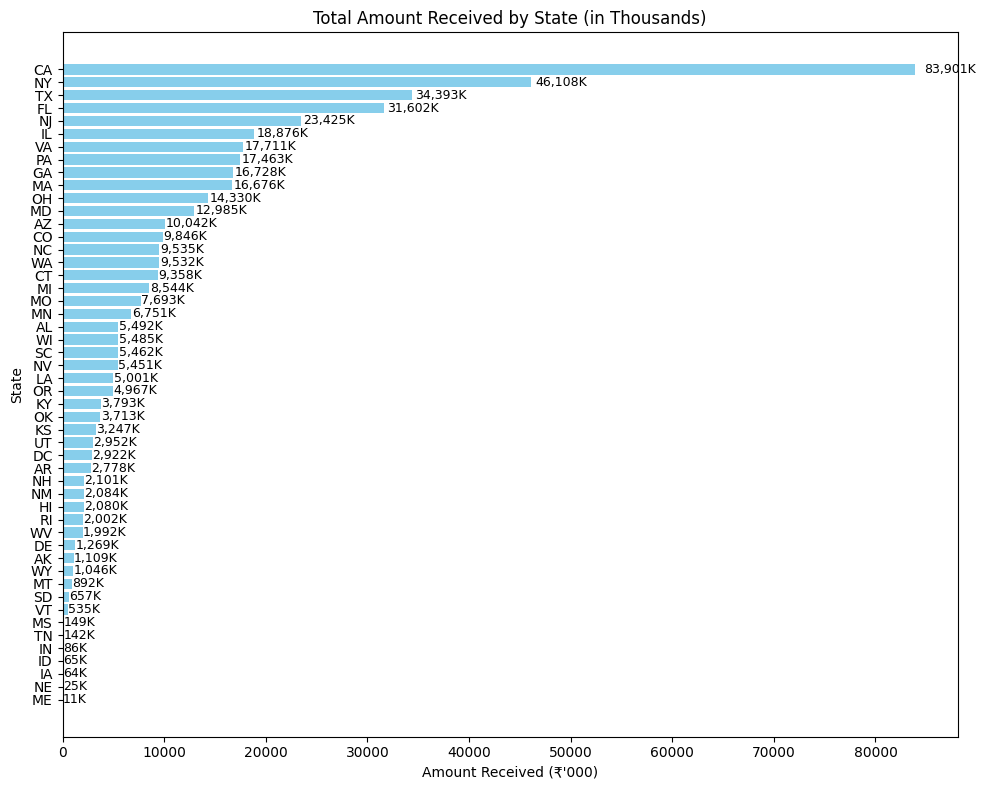

In [9]:
state_received = df.groupby('address_state')['total_payment'].sum().sort_values(ascending=True)

state_received_thousands = state_received / 1000

plt.figure(figsize=(10, 8))
bars = plt.barh(state_received_thousands.index,
                state_received_thousands.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f'{width:,.0f}K',
             va='center',
             fontsize=9)

plt.title('Total Amount Received by State (in Thousands)')
plt.xlabel("Amount Received (₹'000)")
plt.ylabel('State')
plt.tight_layout()
plt.show()


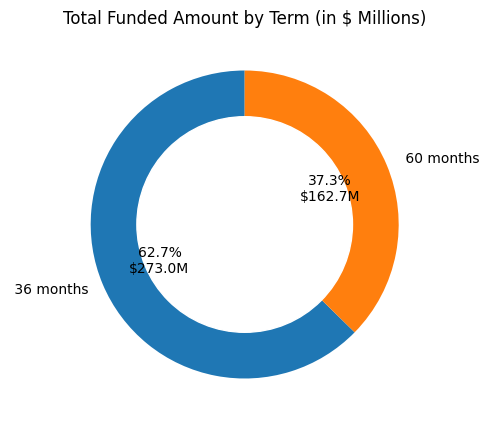

In [15]:
#Total Funded Amount by Term
term_funding_millions = df.groupby('term')['loan_amount'].sum() / 1_000_000

plt.figure(figsize=(5, 5))
plt.pie(
    term_funding_millions,
    labels=term_funding_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*term_funding_millions.sum()/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Funded Amount by Term (in $ Millions)")
plt.show()


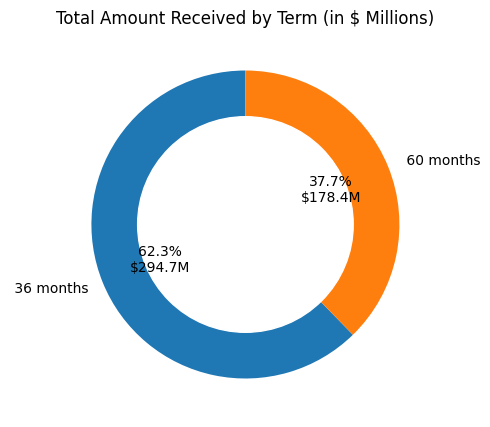

In [16]:
#Total Amount Received by Term
term_received_millions = df.groupby('term')['total_payment'].sum() / 1_000_000

plt.figure(figsize=(5, 5))
plt.pie(
    term_received_millions,
    labels=term_received_millions.index,
    autopct=lambda p: f"{p:.1f}%\n${p*term_received_millions.sum()/100:.1f}M",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Amount Received by Term (in $ Millions)")
plt.show()


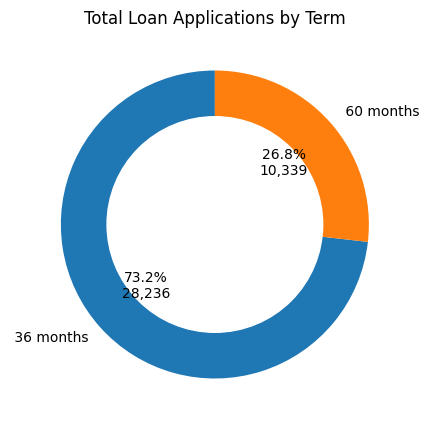

In [17]:
#Total Loan Applications by Term
term_applications = df.groupby('term')['id'].count()

plt.figure(figsize=(5, 5))
plt.pie(
    term_applications,
    labels=term_applications.index,
    autopct=lambda p: f"{p:.1f}%\n{int(p*term_applications.sum()/100):,}",
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.gca().add_artist(plt.Circle((0, 0), 0.70, color='white'))
plt.title("Total Loan Applications by Term")
plt.show()


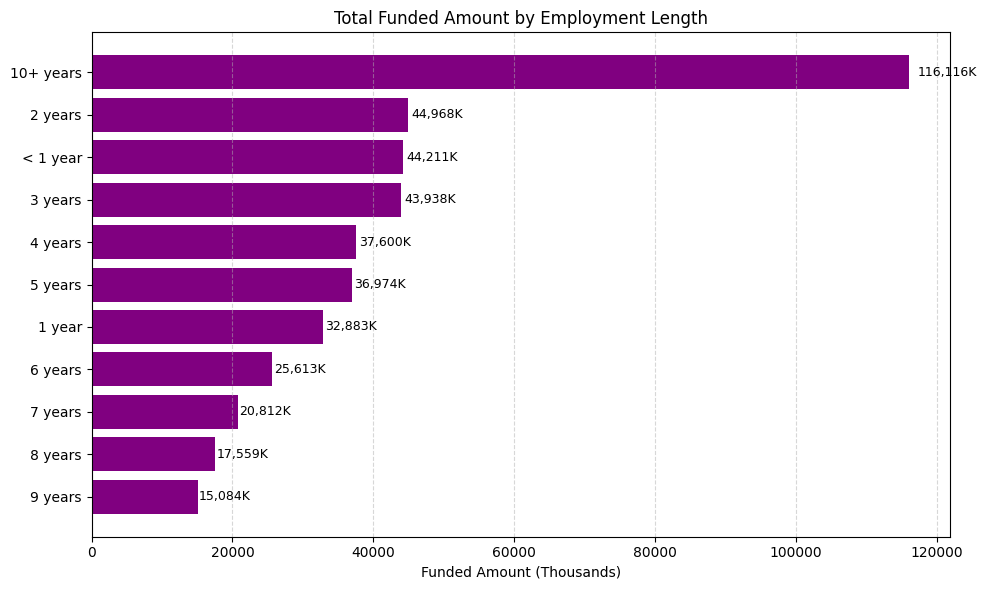

In [19]:
#Employee Length by Total Funded Amount
emp_funding_thousands = df.groupby('emp_length')['loan_amount'] \
                           .sum() \
                           .sort_values() / 1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_funding_thousands.index,
                emp_funding_thousands.values,
                color="purple")

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}K",
             va='center',
             fontsize=9)

plt.xlabel("Funded Amount (Thousands)")
plt.title("Total Funded Amount by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


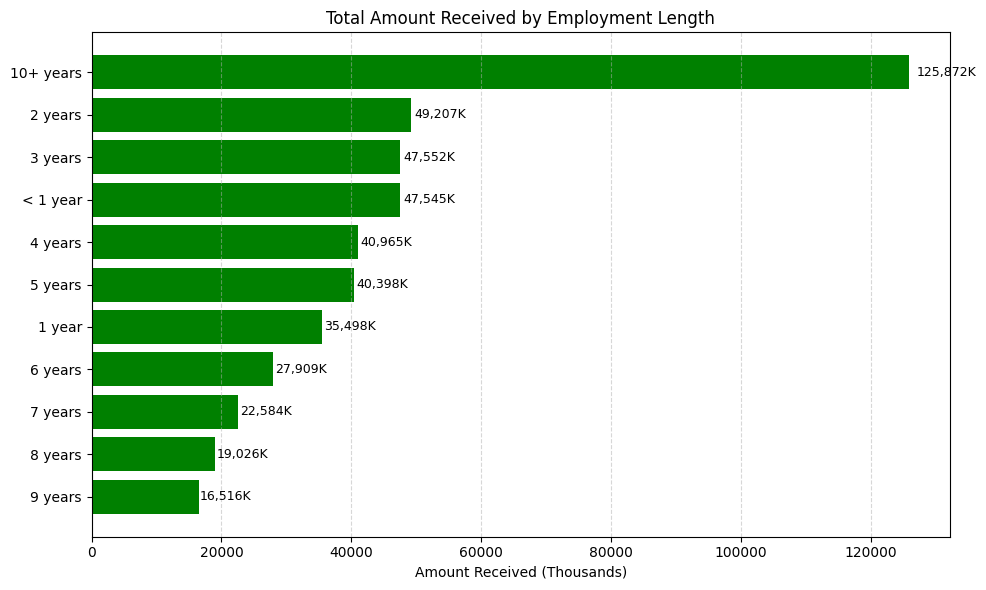

In [20]:
#Employee Length by Total Amount Received
emp_received_thousands = df.groupby('emp_length')['total_payment'] \
                            .sum() \
                            .sort_values() / 1000

plt.figure(figsize=(10, 6))
bars = plt.barh(emp_received_thousands.index,
                emp_received_thousands.values,
                color="green")

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f"{width:,.0f}K",
             va='center',
             fontsize=9)

plt.xlabel("Amount Received (Thousands)")
plt.title("Total Amount Received by Employment Length")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


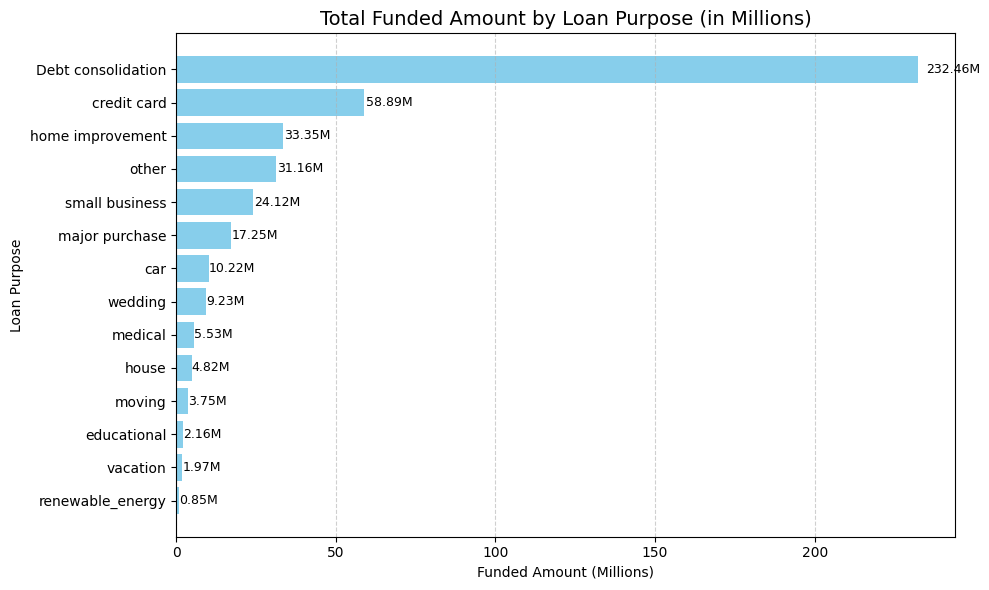

In [21]:
# Loan Purpose by Total Funded Amount

purpose_funding_millions = df.groupby('purpose')['loan_amount'] \
                              .sum() \
                              .sort_values() / 1_000_000

plt.figure(figsize=(10, 6))

bars = plt.barh(purpose_funding_millions.index,
                purpose_funding_millions.values,
                color='skyblue')

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f"{width:,.2f}M",
             va='center',
             fontsize=9)

plt.title("Total Funded Amount by Loan Purpose (in Millions)", fontsize=14)
plt.xlabel("Funded Amount (Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


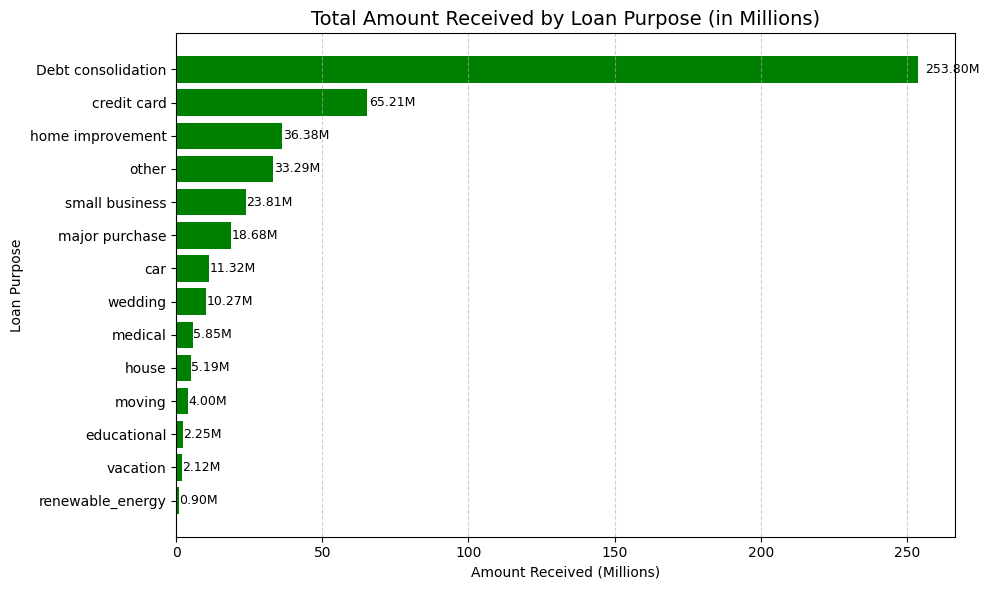

In [22]:
# Loan Purpose by Total Amount Received

purpose_received_millions = df.groupby('purpose')['total_payment'] \
                               .sum() \
                               .sort_values() / 1_000_000

plt.figure(figsize=(10, 6))

bars = plt.barh(purpose_received_millions.index,
                purpose_received_millions.values,
                color='green')

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f"{width:,.2f}M",
             va='center',
             fontsize=9)

plt.title("Total Amount Received by Loan Purpose (in Millions)", fontsize=14)
plt.xlabel("Amount Received (Millions)")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


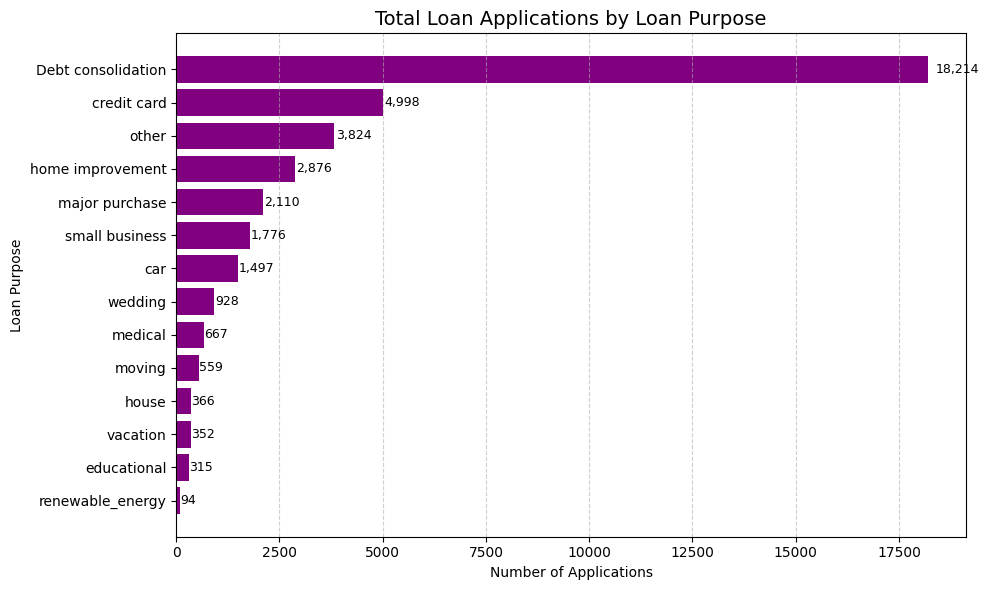

In [23]:
# Loan Purpose by Total Loan Applications

purpose_applications = df.groupby('purpose')['id'] \
                          .count() \
                          .sort_values()

plt.figure(figsize=(10, 6))

bars = plt.barh(purpose_applications.index,
                purpose_applications.values,
                color='purple')

for bar in bars:
    width = bar.get_width()
    plt.text(width * 1.01,
             bar.get_y() + bar.get_height() / 2,
             f"{width:,}",
             va='center',
             fontsize=9)

plt.title("Total Loan Applications by Loan Purpose", fontsize=14)
plt.xlabel("Number of Applications")
plt.ylabel("Loan Purpose")
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [24]:
import plotly.express as px

# Grouping and calculating funded amount in millions
home_funding = df.groupby('home_ownership')['loan_amount'] \
                  .sum() \
                  .reset_index()

home_funding['loan_amount_millions'] = home_funding['loan_amount'] / 1_000_000

# Creating Treemap
fig = px.treemap(
    home_funding,
    path=['home_ownership'],
    values='loan_amount_millions',
    color='loan_amount_millions',
    color_continuous_scale='Blues',
    title='Total Funded Amount by Home Ownership (in Millions)'
)

fig.show()
